# Strategic Asset Allocation — derivation

**Michael's book · CAD base currency · derived 2026**

This notebook derives the target allocation and shows the working. It is the
narrative layer: every calculation lives in `core/` and `analysis/`, and this
notebook calls that code rather than reimplementing it, so the numbers here and
the numbers in the dashboard cannot drift apart — both come from
`core.saa.run_saa()`.

## What this notebook now does that the previous version did not

The earlier version of this notebook was explicitly a *diagnostic* pass: it
measured correlations, VaR and factor loadings, and deliberately stopped short
of setting weights. That was the right call at the time — running an optimiser
over unvalidated inputs produces weights that look authoritative and are not.
The inputs have since been rebuilt, so this version completes the job:

| | Before | Now |
|---|---|---|
| Returns | price only (`Close.pct_change()`) | total return, distributions included |
| Currency | mixed, unconverted | every portfolio statistic in CAD |
| FX alignment | — | Yahoo's one-day timestamp offset corrected |
| History | 4.7 yrs (common window, no crash in it) | 19 yrs via index-proxy backfill |
| Covariance | raw sample | Ledoit-Wolf shrunk, blended with bear-regime |
| Expected returns | sample means | reverse-optimised equilibrium + stated views |
| Weights | none | five objectives, resampled, blended, constrained |
| Validation | — | walk-forward out-of-sample refit |

## The problem this design exists to avoid

Handing a mean-variance optimiser sample means and a sample covariance matrix
produces a two- or three-asset portfolio almost every time. That is not a bug in
the optimiser; it is the optimiser correctly maximising an objective built from
inputs whose estimation error swamps their signal.

The arithmetic is blunt. The standard error of a mean return estimated over $T$
years on a $\sigma$-volatility asset is $\sigma/\sqrt{T}$. Over 19 years of a
19%-volatility asset that is **4.4% per year** — wider than the entire plausible
spread of expected returns across the equity sleeves in this book. Sample means
simply cannot rank these assets. Any allocation that leans on them is expressing
noise, and the optimiser will pile into whichever asset noise happened to
flatter.

Four independent mechanisms address it here, and the effect of each is measured
in section 6 rather than assumed.

## 0 · Setup

In [1]:
import sys, warnings
from pathlib import Path

# Importable whether run from the repo root or from notebooks/.
root = Path.cwd().resolve()
if not (root / "core").exists() and (root.parent / "core").exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# Chart styling matches the dashboard: same categorical order, same recessive
# grid, so a chart means the same thing in both places.
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
       "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (11, 4.6), "figure.dpi": 110,
    "axes.prop_cycle": plt.cycler(color=CAT),
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "axes.edgecolor": "#e8e7e3", "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "600", "axes.titlepad": 12,
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "legend.frameon": False,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
})
PCT = mtick.PercentFormatter(xmax=1.0)
print("Ready.")

Ready.


## 1 · The data foundation

Three corrections were made before any allocation work, because each one changes
the answer materially and none of them is visible in a weight vector.

### 1.1 Total return, not price return

`Close.pct_change()` silently discards every distribution. For most equity ETFs
that is a 2%/yr understatement. For `CASH.TO` and `XFR.TO` it is close to the
*entire* return: these instruments hold their price near par and pay everything
out. A price-return optimiser sees them as assets with roughly zero expected
return and a small positive volatility, and refuses to hold them at all.

In [2]:
from core.universe import build_michael_portfolio
from core.returns import reconciliation_report, summary_stats, total_return_series
from core.data_loader import get_price_history

portfolio = build_michael_portfolio()
portfolio.fetch_all_prices()

rows = {}
for s in portfolio.securities:
    px = s.prices["Close"].dropna()
    price_only = float(px.iloc[-1] / px.iloc[0] - 1)
    total = float((1 + total_return_series(s.prices, s.currency)).prod() - 1)
    rows[s.ticker] = {
        "price return": price_only,
        "total return": total,
        "gap from distributions": total - price_only,
        "years": round(len(px) / 252, 1),
    }
gap = pd.DataFrame(rows).T.sort_values("gap from distributions", ascending=False)
gap.style.format({"price return": "{:.1%}", "total return": "{:.1%}",
                  "gap from distributions": "{:+.1%}"})

,price return,total return,gap from distributions,years
CAR-UN.TO,191.0%,1183.7%,+992.6%,27.200000
XIC.TO,345.8%,745.8%,+400.0%,25.400000
VTV,354.7%,715.9%,+361.1%,22.500000
VEE.TO,98.1%,173.1%,+75.0%,14.500000
XUU.TO,283.6%,349.3%,+65.7%,11.500000
VIU.TO,100.1%,159.5%,+59.3%,10.700000
XFR.TO,0.1%,32.4%,+32.3%,14.700000
AVUV,147.2%,175.7%,+28.5%,6.900000
CASH.TO,0.0%,16.9%,+16.9%,4.800000
VOLX.TO,-100.0%,-100.0%,+0.0%,15.600000


`XFR.TO` and `CASH.TO` show the pattern most sharply — nearly all of their
cumulative return is distributions, and essentially none is price appreciation.

`VOLX.TO` is the other extreme and is dealt with in section 7.

### 1.2 Two independent reconstructions must agree

Total returns are rebuilt from close prices plus distributions, then
cross-checked against Yahoo's own `Adj Close`. The two are computed from
different inputs, so a large gap means one of them is corrupt for that ticker.

In [3]:
rec = reconciliation_report(portfolio.securities)
print(f"Tickers flagged for investigation: {(rec['flag'] == 'INVESTIGATE').sum()} of {len(rec)}")
rec.round(4)

Tickers flagged for investigation: 0 of 11


,cum_total_return_reconstructed,cum_total_return_adj_close,max_daily_abs_diff,flag
ticker,,,,
XFR.TO,0.3238,0.3239,0.0000,ok
CASH.TO,0.1690,0.1672,0.0017,ok
XUU.TO,3.4933,3.4920,0.0001,ok
VTV,7.1588,7.1590,0.0006,ok
AVUV,1.7571,1.7571,0.0004,ok
XIC.TO,7.4584,7.3901,0.0042,ok
VIU.TO,1.5947,1.5938,0.0002,ok
VEE.TO,1.7312,1.7307,0.0002,ok
CGL.TO,1.7627,1.7627,0.0000,ok


### 1.3 The FX timestamp correction

This one is easy to miss and expensive to get wrong.

The book is held in two currencies but spent in CAD, so every portfolio-level
statistic has to be computed on CAD-converted returns. Yahoo's `CAD=X` daily bar,
however, is **stamped one calendar day ahead** of the session it describes — the
series carries a bar dated tomorrow while every equity feed ends today.

Left uncorrected, each USD holding's CAD return pairs an equity move with the
wrong day's FX move. The two mismatched shocks then add in quadrature instead of
partially offsetting, and the modelled volatility of the entire US sleeve
inflates.

The test below compares `XUU.TO` — a CAD-listed, unhedged US total-market ETF —
against VTI converted to CAD. These are the same underlying exposure, so a
correct FX alignment should make them nearly identical.

In [4]:
xuu = total_return_series(get_price_history("XUU.TO"), "CAD")
vti = total_return_series(get_price_history("VTI"), "USD")
fx_raw = get_price_history("CAD=X")["Close"].dropna()

fx_fixed = fx_raw.copy()
fx_fixed.index = fx_fixed.index - pd.tseries.offsets.BDay(1)

out = {}
for label, series in [("Yahoo stamps as-is", fx_raw), ("Shifted back 1 business day", fx_fixed)]:
    r = series.pct_change().dropna()
    j = pd.concat({"xuu": xuu, "vti": vti, "fx": r}, axis=1, sort=True).dropna()
    synthetic = j["vti"] + j["fx"]
    out[label] = {
        "correlation to XUU.TO": j["xuu"].corr(synthetic),
        "modelled vol / true vol": synthetic.std() / j["xuu"].std(),
        "overlapping days": len(j),
    }
fxcmp = pd.DataFrame(out).T

xic = total_return_series(get_price_history("XIC.TO"), "CAD")
gsp = get_price_history("^GSPTSE")["Close"].pct_change().dropna()
ceiling = pd.concat({"a": xic, "b": gsp}, axis=1, sort=True).dropna().corr().iloc[0, 1]

print(fxcmp.round(4).to_string())
print(f"\nPractical ceiling for daily TSX close data (XIC.TO vs its own index ^GSPTSE): {ceiling:.3f}")

                             correlation to XUU.TO  modelled vol / true vol  overlapping days
Yahoo stamps as-is                          0.8042                   1.1550        2,834.0000
Shifted back 1 business day                 0.9094                   0.9912        2,831.0000

Practical ceiling for daily TSX close data (XIC.TO vs its own index ^GSPTSE): 0.973


**The uncorrected series inflates the US sleeve's modelled volatility by about
15% and destroys ten points of correlation.** A mean-variance optimiser fed that
version would underweight US equity for a reason that is purely a data-vendor
timestamp artefact — and nothing in the output would reveal why.

The correction is applied in `core/fx.py` and is a correction, not a look-ahead:
the bar Yahoo labels $t{+}1$ is the rate that prevailed during session $t$, which
is exactly why a bar dated tomorrow already exists while equity feeds end today.

### 1.4 Proxy backfill — buying back the crashes

Inner-joining all holdings on dates where every one of them traded leaves a
common window starting **November 2021**: 4.7 years. The bigger problem is not
the length, it is *which* 4.7 years. That window contains no 2008 and no 2020.
An allocation built on it would be calibrated entirely to one post-COVID
rate-hiking regime, and every "does diversification survive a crash" test would
be answered with a sample containing no crash.

Six holdings therefore get a long-lived index proxy spliced onto the front of
their own history. Real returns always win where they exist; the proxy fills only
the pre-inception gap.

In [5]:
from core.proxies import PROXY_MAP, extended_returns_frame, proxy_quality_report

secs = [s for s in portfolio.securities if s.ticker != "VOLX.TO"]
qr = proxy_quality_report(secs)
print(qr.round(3).to_string())

naive = pd.DataFrame({s.ticker: total_return_series(s.prices, s.currency, in_cad=True)
                      for s in secs}).dropna(how="any")
spliced, sources = extended_returns_frame(secs, min_start="2007-05-31", align=True)
print(f"\nUnspliced common window : {naive.index.min():%Y-%m-%d} to {naive.index.max():%Y-%m-%d}"
      f"  ({len(naive):,} days, {len(naive)/252:.1f} years)")
print(f"Spliced analysis window : {spliced.index.min():%Y-%m-%d} to {spliced.index.max():%Y-%m-%d}"
      f"  ({len(spliced):,} days, {len(spliced)/252:.1f} years)")

               overlap_days  overlap_corr  tracking_error_ann  vol_ratio         verdict
ticker  proxy                                                                           
XFR.TO  FLOT           3622        0.3720              0.0180     1.0140   rate-proxy ok
        BIL            3622        0.0130              0.0230     0.9970  RATE-PROXY OFF
CASH.TO BIL            1183        0.0930              0.0080     1.0000   rate-proxy ok
XUU.TO  VTI            2838        0.9080              0.0710     0.9930      acceptable
AVUV    VBR            1740        0.9390              0.0880     0.9480      acceptable
        IWN            1740        0.9470              0.0850     1.0190      acceptable
VIU.TO  VEA            2640        0.9390              0.0530     0.9830      acceptable
        EFA            2640        0.9370              0.0540     0.9840      acceptable
VEE.TO  VWO            3596        0.9640              0.0460     1.0070          strong
        EEM          


Unspliced common window : 2021-11-04 to 2026-09-01  (1,183 days, 4.7 years)
Spliced analysis window : 2007-05-31 to 2026-09-01  (4,743 days, 18.8 years)


findfont: Failed to find font weight 600, now using 700.


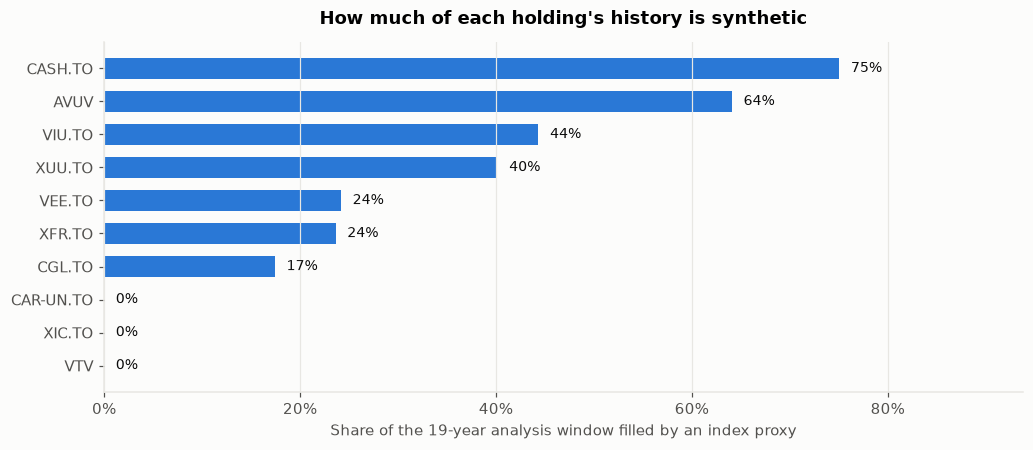

In [6]:
synth_share = (sources.map(lambda x: str(x).startswith("~")).mean()).sort_values()

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.barh(synth_share.index, synth_share.values, color=CAT[0], height=0.62)
for i, v in enumerate(synth_share.values):
    ax.text(v + 0.012, i, f"{v:.0%}", va="center", fontsize=9, color="#0b0b0b")
ax.set_xlim(0, max(synth_share.max() * 1.25, 0.1))
ax.xaxis.set_major_formatter(PCT)
ax.set_xlabel("Share of the 19-year analysis window filled by an index proxy")
ax.set_title("How much of each holding's history is synthetic")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

The splice quality table above is the audit. Overlap correlations of 0.88–0.96
and volatility ratios within a few percent of 1.0 mean the proxies carry the
right exposure at the right risk scale.

The two cash-like sleeves are judged differently and deliberately so. Their daily
co-movement with a proxy is mostly microstructure noise on a near-riskless
instrument; what is being borrowed from `BIL`/`FLOT` is the *short-rate path*
(near zero 2009–2015, ~2% in 2018, near zero in 2020–21, ~5% in 2023), not a
correlation. They are therefore volatility-matched — scaling only the residual
around a rolling mean, never the carry, since scaling the whole series would have
multiplied the modelled cash yield along with its risk.

This is an estimate, and it is used only for covariance, regime and stress work.
It is never presented as a holding's own track record.

## 2 · Run the model

Everything from here is `core.saa.run_saa()`, which chains the pipeline:
returns → regime → covariance → equilibrium returns → views → five objectives →
resampling → blend → rounding.

In [7]:
from core.saa import run_saa, save_result, reference_allocations

result = run_saa(
    bear_weight=0.35,          # how far covariance is priced off crash behaviour
    drawdown_threshold=0.10,   # what counts as "bear"
    n_resamples=120,           # Michaud resamples per objective
    resample=True,
    rf=0.0275,
    risk_aversion=2.8,
    verbose=True,
)
save_result(result)

[saa] Building universe and fetching prices...


[saa] Splicing proxy history and building CAD total returns...


[saa] Window: 2007-05-31 -> 2026-09-01 (4743 days)
[saa] Bear regime: 1684 of 4743 days (35.5%) at a 10% drawdown threshold.
[saa] Estimating regime-blended shrunk covariance...
[saa] Reverse-optimising equilibrium returns and applying thesis views...
[saa] Solving 5 objectives x 120 resamples...


[saa] Done. 10 positions, effective N = 8.1 (risk-based 7.3), expected 7.19% at 11.25% vol.


WindowsPath('C:/Users/mginf/OneDrive/Documents/porfolio-saa-project/outputs/saa_result.pkl')

## 3 · Defining "bear" correctly

The previous version classified regimes off `^GSPTSE` drawdowns. That is the
wrong benchmark for this book, and not by a small margin: the TSX is roughly 3%
of world market capitalisation and about 60% financials plus energy. It has had
drawdowns this globally diversified portfolio barely felt, and missed some it
felt sharply.

"Bear" here means **the equity risk this investor actually holds is in a
drawdown** — an equal-weighted index of the book's own six equity sleeves, in
CAD.

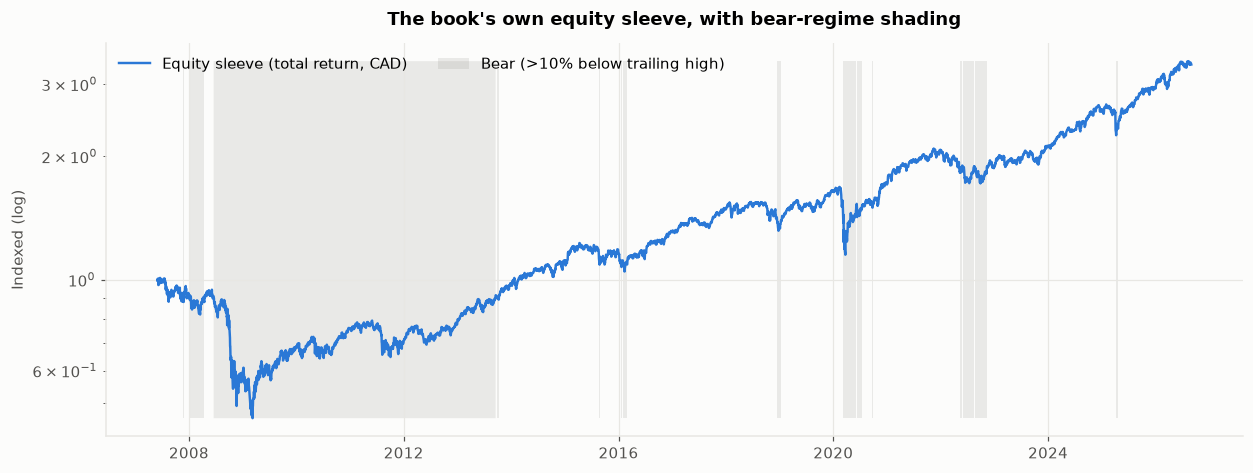

Bear days: 1,684 of 4,743 (35.5%)
Bear episodes: 41


In [8]:
eq_idx = result.equity_index
bear = result.bear_mask

fig, ax = plt.subplots(figsize=(11.5, 4.4))
ax.plot(eq_idx.index, eq_idx.values, color=CAT[0], lw=1.6, label="Equity sleeve (total return, CAD)")
ax.fill_between(eq_idx.index, eq_idx.min(), eq_idx.max(), where=bear.values,
                color="#8a8880", alpha=0.16, lw=0, label="Bear (>10% below trailing high)")
ax.set_yscale("log"); ax.set_ylabel("Indexed (log)")
ax.set_title("The book's own equity sleeve, with bear-regime shading")
ax.legend(loc="upper left", ncol=2)
plt.tight_layout(); plt.show()

print(f"Bear days: {int(bear.sum()):,} of {len(bear):,} ({bear.mean():.1%})")
print(f"Bear episodes: {int((bear.astype(int).diff() == 1).sum())}")

### 3.1 The question the whole thesis rests on

Gold, floating-rate notes and non-US equity are held because they are expected to
behave *differently in a crash*. An unconditional correlation over 19 mostly-calm
years says almost nothing about that: two assets can correlate 0.1 on average and
0.85 in every drawdown that ever mattered.

So the correlation matrix is split by regime, and the third panel — the
difference — is the one that matters.

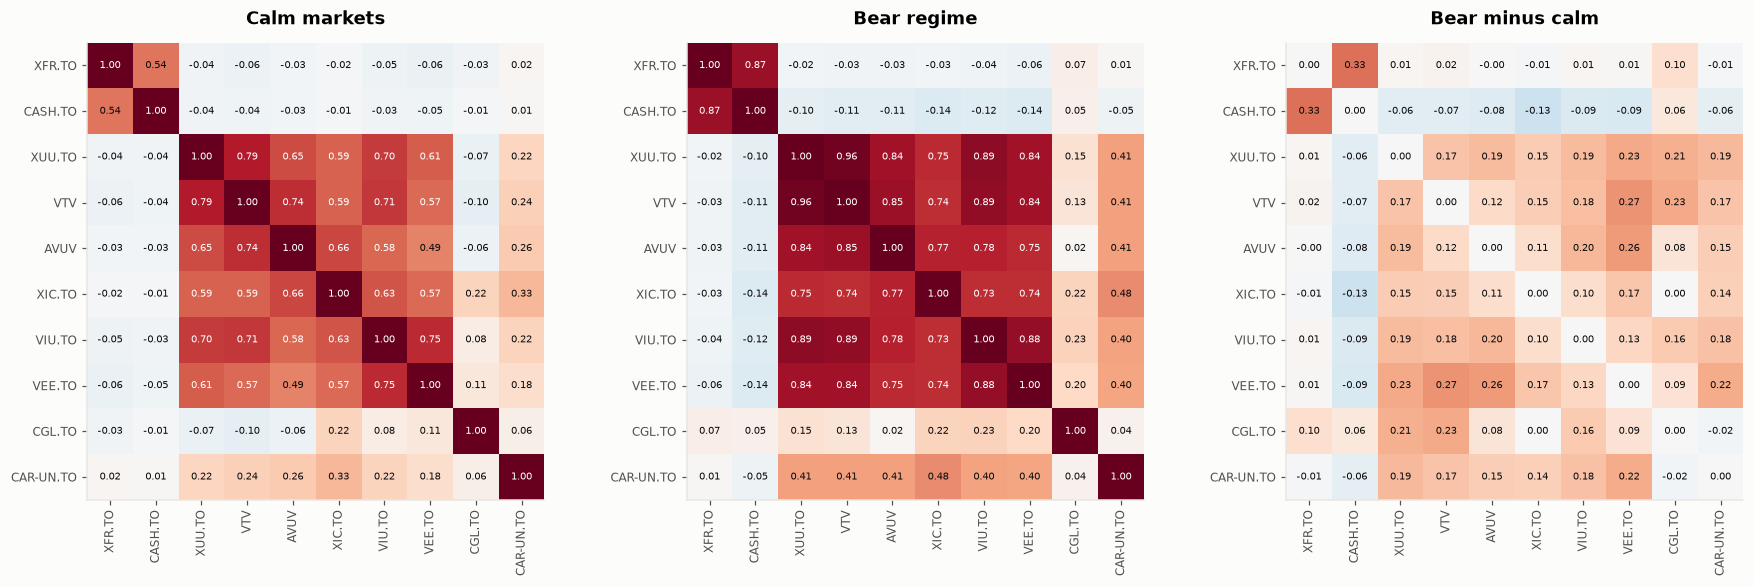

In [9]:
rets = result.returns
calm_c = rets.loc[~bear].corr()
bear_c = rets.loc[bear].corr()
delta_c = bear_c - calm_c

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))
for ax, (mat, title, vlim) in zip(axes, [(calm_c, "Calm markets", 1.0),
                                         (bear_c, "Bear regime", 1.0),
                                         (delta_c, "Bear minus calm", 0.6)]):
    im = ax.imshow(mat.values, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
    ax.set_xticks(range(len(mat)), mat.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(len(mat)), mat.index, fontsize=8)
    ax.set_title(title)
    ax.grid(False)
    for i in range(len(mat)):
        for j in range(len(mat)):
            ax.text(j, i, f"{mat.values[i, j]:.2f}", ha="center", va="center", fontsize=6.5,
                    color="#0b0b0b" if abs(mat.values[i, j]) < vlim * 0.55 else "white")
plt.tight_layout(); plt.show()

In [10]:
from analysis.stress import correlation_regime_table, tail_dependence, up_down_beta

reg = correlation_regime_table(rets, "XUU.TO", quantile=0.10)
print("Correlation to XUU.TO: calm markets vs XUU.TO's own worst decile\n")
print(reg.round(3).to_string())

gold = reg.loc["CGL.TO"]
print(f"\nGOLD AS TAIL HEDGE — the thesis's central hedging claim:")
print(f"  calm-market correlation to core US equity : {gold['calm_corr']:+.2f}")
print(f"  worst-decile correlation                  : {gold['stress_corr']:+.2f}")
print(f"  change                                    : {gold['stress_uplift']:+.2f}")

Correlation to XUU.TO: calm markets vs XUU.TO's own worst decile

           calm_corr  stress_corr  stress_uplift
XIC.TO        0.5830       0.7060         0.1240
CAR-UN.TO     0.2350       0.3140         0.0790
VEE.TO        0.6710       0.7220         0.0500
AVUV          0.6840       0.7260         0.0410
CGL.TO        0.0360       0.0720         0.0360
VTV           0.8640       0.8850         0.0210
VIU.TO        0.7630       0.7750         0.0120
XFR.TO       -0.0160      -0.0430        -0.0270
CASH.TO      -0.0300      -0.1800        -0.1510

GOLD AS TAIL HEDGE — the thesis's central hedging claim:
  calm-market correlation to core US equity : +0.04
  worst-decile correlation                  : +0.07
  change                                    : +0.04


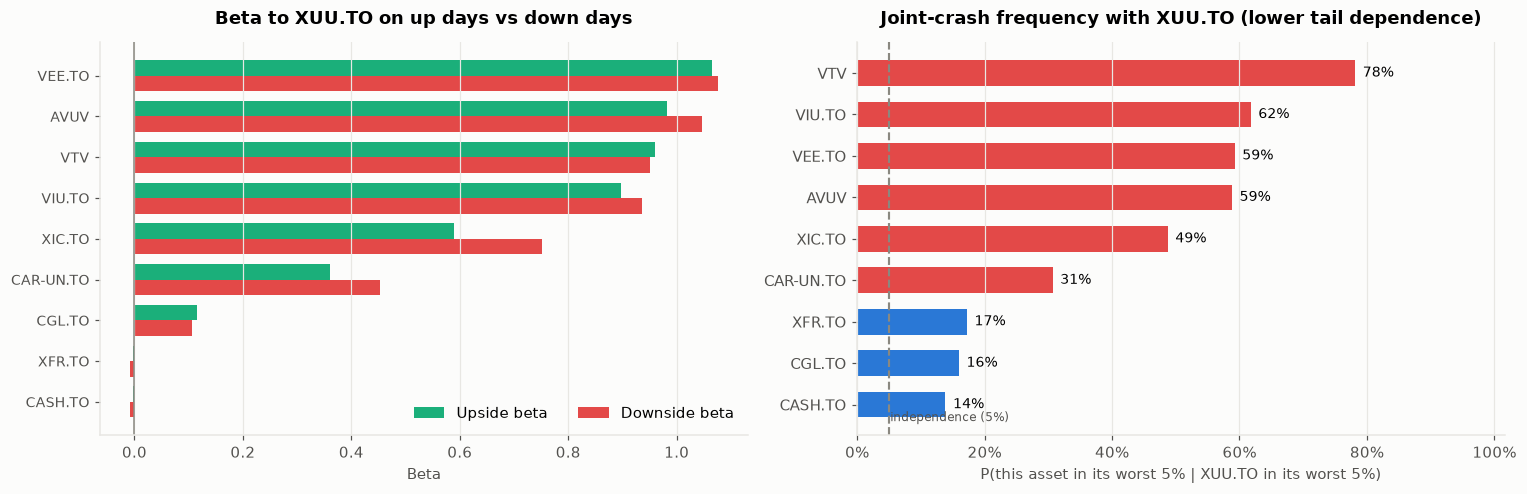

In [11]:
ud = up_down_beta(rets, "XUU.TO")
td = tail_dependence(rets, "XUU.TO", quantile=0.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

o = ud.sort_values("downside_beta")
y = np.arange(len(o)); h = 0.38
axes[0].barh(y + h/2, o["upside_beta"], height=h, color=CAT[2], label="Upside beta")
axes[0].barh(y - h/2, o["downside_beta"], height=h, color=CAT[7], label="Downside beta")
axes[0].set_yticks(y, o.index, fontsize=9)
axes[0].axvline(0, color="#8a8880", lw=1)
axes[0].set_title("Beta to XUU.TO on up days vs down days")
axes[0].set_xlabel("Beta"); axes[0].legend(ncol=2); axes[0].grid(axis="y", visible=False)

t = td.sort_values()
axes[1].barh(t.index, t.values, color=[CAT[7] if v > 0.25 else CAT[0] for v in t.values], height=0.62)
axes[1].axvline(0.05, color="#8a8880", lw=1.4, ls="--")
axes[1].text(0.052, -0.4, "independence (5%)", fontsize=8, color="#52514e")
for i, v in enumerate(t.values):
    axes[1].text(v + 0.012, i, f"{v:.0%}", va="center", fontsize=9)
axes[1].xaxis.set_major_formatter(PCT)
axes[1].set_xlim(0, t.max() * 1.3)
axes[1].set_title("Joint-crash frequency with XUU.TO (lower tail dependence)")
axes[1].set_xlabel("P(this asset in its worst 5% | XUU.TO in its worst 5%)")
axes[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Reading these two charts.** Downside beta materially above upside beta is the
worst possible profile — the asset takes the losses without the gains — and it is
invisible to correlation, which is symmetric by construction. Tail dependence
answers a question correlation cannot: given core US equity had a bottom-5% day,
how often did this holding *also* have one? Independence would sit near 5%.

This is exactly why the covariance matrix the optimiser sees is a blend of the
calm and bear matrices rather than the calm one alone. Optimising on average
behaviour buys diversification that history says evaporates precisely when it is
needed.

## 4 · Covariance: shrunk, then regime-blended

Two adjustments, in order.

**Ledoit-Wolf shrinkage.** Sample covariance over 10 assets and ~4,700 days is
estimable, but its smallest eigenvalues are biased downward — and those are
exactly the directions a minimum-variance optimiser loads into. Shrinking toward
a structured target pulls them back.

**Bear blend.** $\Sigma = (1-w)\,\Sigma_{\text{full}} + w\,\Sigma_{\text{bear}}$,
with $w = 0.35$. This is a *risk preference*, not an estimate: it says how much
the allocation should be priced off crash behaviour. At $w=0$ it reduces to the
ordinary shrunk matrix; at $w=1$ the book is optimised as though the market were
permanently in a drawdown, which over-hedges. The default roughly matches the
observed frequency of bear days, and it is a dashboard slider rather than a
buried constant.

In [12]:
d = result.cov_diagnostics
print(f"Ledoit-Wolf shrinkage, full sample : {d['shrinkage_full']:.4f}")
print(f"Ledoit-Wolf shrinkage, bear subsample: {d['shrinkage_bear']:.4f}")
print(f"Bear observations used             : {d['bear_days']:,}")

vol = pd.DataFrame({"Full sample": d["vol_full"], "Bear regime": d["vol_bear"]})
vol["uplift"] = vol["Bear regime"] / vol["Full sample"] - 1
print("\nAnnualised volatility by regime:")
print(vol.sort_values("uplift", ascending=False).round(4).to_string())

Ledoit-Wolf shrinkage, full sample : 0.0052
Ledoit-Wolf shrinkage, bear subsample: 0.0087
Bear observations used             : 1,684

Annualised volatility by regime:
           Full sample  Bear regime  uplift
CASH.TO         0.0169       0.0277  0.6375
XFR.TO          0.0335       0.0528  0.5791
XIC.TO          0.1697       0.2431  0.4321
VTV             0.1893       0.2680  0.4159
VIU.TO          0.2014       0.2841  0.4104
VEE.TO          0.2464       0.3446  0.3984
XUU.TO          0.1908       0.2613  0.3699
AVUV            0.2428       0.3301  0.3597
CAR-UN.TO       0.2215       0.2758  0.2453
CGL.TO          0.1937       0.2366  0.2214


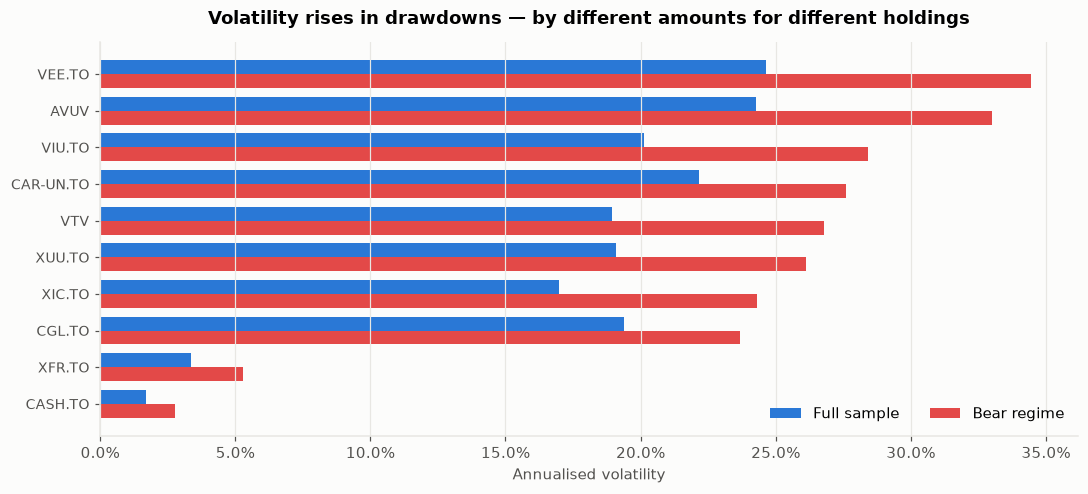

In [13]:
v = vol.sort_values("Bear regime")
y = np.arange(len(v)); h = 0.38
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.barh(y + h/2, v["Full sample"], height=h, color=CAT[0], label="Full sample")
ax.barh(y - h/2, v["Bear regime"], height=h, color=CAT[7], label="Bear regime")
ax.set_yticks(y, v.index, fontsize=9)
ax.xaxis.set_major_formatter(PCT)
ax.set_xlabel("Annualised volatility")
ax.set_title("Volatility rises in drawdowns — by different amounts for different holdings")
ax.legend(ncol=2); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 5 · Expected returns without forecasting

The model never asks history what each asset will return. Instead it
**reverse-optimises**: given the covariance matrix, what set of expected returns
would make a sensible reference allocation optimal?

$$\pi = \delta\,\Sigma\,w_{\text{ref}} + r_f$$

The virtue is internal consistency. $\pi$ is generated by the same covariance
matrix the optimiser will use, so feeding it back reproduces the reference
weights exactly and **cannot** produce a corner solution. Every deviation from
the reference therefore has to be argued for by an explicit view, rather than
smuggled in by sampling noise.

The thesis is then applied as Black-Litterman views. Each is *relative*
("this beats that"), because that is what the thesis actually claims, and each
carries a confidence that is the fraction of the way the posterior moves from the
prior toward the view — not a probability.

In [14]:
from core.policy import REFERENCE_WEIGHTS, thesis_views

for v in thesis_views():
    picks = "   ".join(f"{'+' if c > 0 else ''}{c:g}·{t}" for t, c in v.picks.items())
    print(f"▸ {v.name}")
    print(f"    {picks}  =  {v.q:+.2%}/yr   (confidence {v.confidence:.0%})")
    print(f"    {v.rationale}\n")

▸ Value tilt over cap-weighted US core
    +0.5·VTV   +0.5·AVUV   -1·XUU.TO  =  +1.25%/yr   (confidence 35%)
    The book's central active claim. Value spreads against growth remain near the wide end of their historical range, and a cap-weighted total-market fund now carries roughly a third of its weight in ten AI-capex-linked names. 1.25%/yr is a modest number by the standards of historical value premia precisely because the premium's timing is unreliable -- the position is justified more by what it avoids than by what it earns.

▸ Ex-North-America equity over US core
    +0.6·VIU.TO   +0.4·VEE.TO   -1·XUU.TO  =  +1.00%/yr   (confidence 25%)
    Same concentration argument, expressed geographically. Developed ex-NA and emerging markets trade at a wide and persistent earnings-multiple discount to the US. Low confidence because that discount has been wide and persistent for over a decade without closing -- it is a valuation argument, and valuation is a poor short-horizon timing tool.

▸

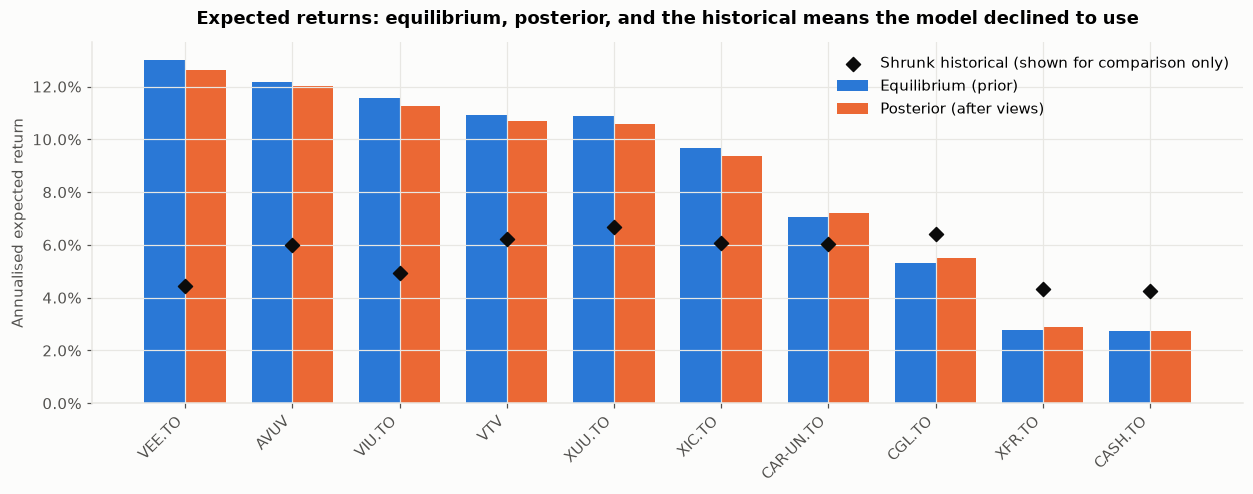

,equilibrium,posterior,view_tilt,shrunk historical
VEE.TO,0.1303,0.1262,-0.0040,0.0445
AVUV,0.1218,0.1203,-0.0016,0.0598
VIU.TO,0.1158,0.1127,-0.0031,0.0495
VTV,0.1092,0.1069,-0.0023,0.0621
XUU.TO,0.1089,0.1056,-0.0033,0.0670
XIC.TO,0.0966,0.0936,-0.0031,0.0609
CAR-UN.TO,0.0706,0.0721,0.0016,0.0604
CGL.TO,0.0531,0.0551,0.0020,0.0642
XFR.TO,0.0278,0.0288,0.0010,0.0431
CASH.TO,0.0272,0.0272,-0.0000,0.0426


In [15]:
det = result.view_detail.copy()
det["shrunk historical"] = result.historical_returns_shrunk
det = det.sort_values("posterior", ascending=False)

x = np.arange(len(det)); w_ = 0.38
fig, ax = plt.subplots(figsize=(11.5, 4.6))
ax.bar(x - w_/2, det["equilibrium"], w_, color=CAT[0], label="Equilibrium (prior)")
ax.bar(x + w_/2, det["posterior"], w_, color=CAT[1], label="Posterior (after views)")
ax.scatter(x, det["shrunk historical"], color="#0b0b0b", zorder=5, s=42, marker="D",
           label="Shrunk historical (shown for comparison only)")
ax.set_xticks(x, det.index, rotation=45, ha="right")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Annualised expected return")
ax.set_title("Expected returns: equilibrium, posterior, and the historical means the model declined to use")
ax.legend()
plt.tight_layout(); plt.show()

det.round(4)

The diamonds are shrunk historical means. They are plotted **only** so the
difference is visible — no weight anywhere in this model is set from them. The
gap between a diamond and its bars is the amount of sampling noise the model
chose not to act on.

Note how far the historical estimates sit from the equilibrium ones for the
international sleeves in particular. `VEE.TO` realised roughly 1.9%/yr over this
window; its equilibrium return is around 13%. Neither is a forecast, but only one
of them is a defensible *input* — a decade of realised emerging-market
underperformance is not evidence that emerging markets have a 1.9% expected
return, and an optimiser fed that number would refuse to hold them at all.

## 6 · Optimisation: five objectives, resampled and blended

Rather than picking one definition of "optimal", five genuinely different
objectives are solved, each Michaud-resampled across 120 block bootstraps, and
the recommendation is their average:

| Objective | Uses expected returns? | Known bias |
|---|---|---|
| Minimum variance | no | hides in cash |
| Equal risk contribution | no | ignores returns entirely |
| Maximum diversification | no | favours volatile-but-uncorrelated assets |
| Maximum Sharpe (Black-Litterman) | yes | chases the highest posterior |
| Minimum CVaR (95%) | no (uses the tail) | fits the worst weeks in the sample |

Averaging estimators that disagree is a cheap and well-established robustness
gain. Where all five agree, the position is genuinely well-founded; where they
disagree, that spread is reported rather than hidden, and it is the honest
measure of how much confidence a weight deserves.

In [16]:
from core.optimizer import STRATEGY_LABELS

sw = result.strategy_weights
disp = (sw * 100).round(1)
disp.columns = [STRATEGY_LABELS[c] for c in sw.columns]
disp["→ BLEND"] = (result.blended_weights * 100).round(1)
disp["→ FINAL"] = (result.final_weights * 100).round(1)
disp

,Minimum variance,Equal risk contribution,Maximum diversification,Max Sharpe (Black-Litterman),Minimum CVaR (95%),→ BLEND,→ FINAL
XFR.TO,16.1000,25.0000,25.0000,21.0000,19.8000,21.4000,21.0000
CASH.TO,18.9000,10.0000,10.0000,9.2000,15.2000,12.7000,12.5000
XUU.TO,8.1000,7.9000,6.4000,7.5000,10.3000,8.0000,8.0000
VTV,8.0000,7.9000,5.7000,11.3000,16.0000,9.8000,10.0000
AVUV,2.0000,6.6000,8.3000,7.8000,2.0000,5.3000,5.5000
XIC.TO,16.9000,9.2000,14.5000,10.0000,6.6000,11.5000,11.5000
VIU.TO,8.0000,7.2000,6.0000,11.6000,7.3000,8.0000,8.0000
VEE.TO,2.0000,6.1000,4.1000,6.5000,3.1000,4.4000,4.5000
CGL.TO,15.0000,15.0000,15.0000,11.4000,15.0000,14.3000,14.5000
CAR-UN.TO,5.0000,5.0000,5.0000,3.6000,4.6000,4.6000,4.5000


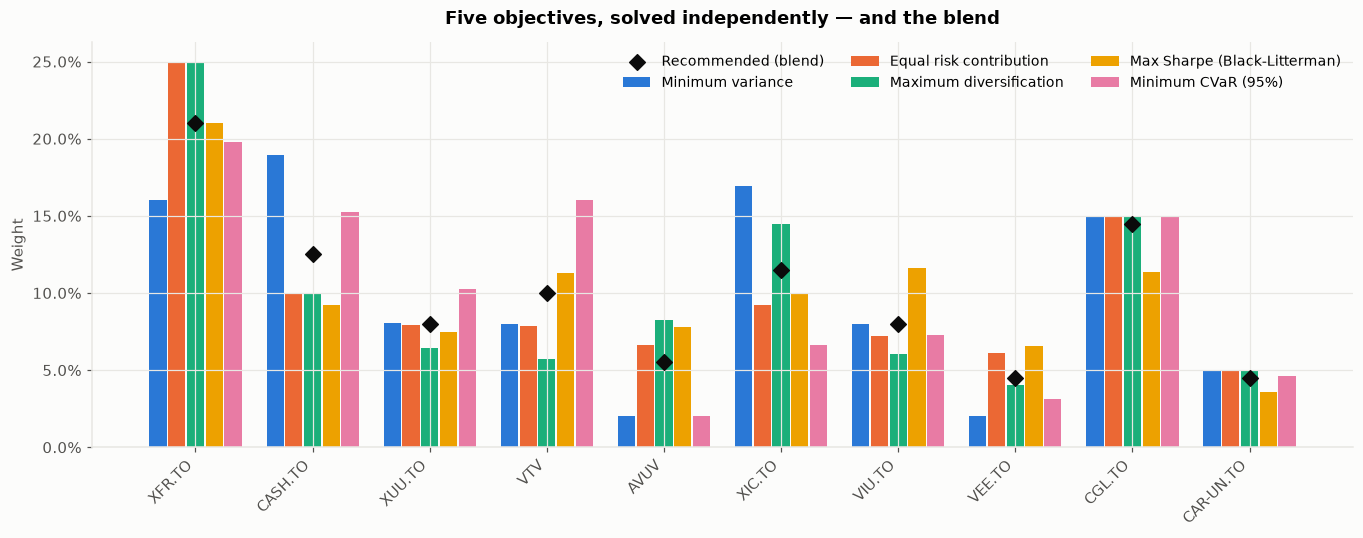

Disagreement across objectives (max − min weight):
XIC.TO      10.3000
VTV         10.3000
CASH.TO      9.7000
XFR.TO       8.9000
AVUV         6.3000
VIU.TO       5.6000
VEE.TO       4.5000
XUU.TO       3.8000
CGL.TO       3.6000
CAR-UN.TO    1.4000


In [17]:
x = np.arange(len(sw)); n = len(sw.columns); w_ = 0.8 / n
fig, ax = plt.subplots(figsize=(12.5, 5))
for i, col in enumerate(sw.columns):
    ax.bar(x + (i - (n - 1) / 2) * w_, sw[col], w_ * 0.92,
           color=CAT[i], label=STRATEGY_LABELS[col])
ax.scatter(x, result.final_weights.reindex(sw.index), color="#0b0b0b",
           marker="D", s=52, zorder=5, label="Recommended (blend)")
ax.set_xticks(x, sw.index, rotation=45, ha="right")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Weight")
ax.set_title("Five objectives, solved independently — and the blend")
ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

spread = (sw.max(axis=1) - sw.min(axis=1)).sort_values(ascending=False)
print("Disagreement across objectives (max − min weight):")
print((spread * 100).round(1).to_string())

### 6.1 Did the anti-concentration machinery actually work?

The claim is that better inputs, not the constraints, are what prevent a
degenerate answer. That is testable: strip the machinery away one layer at a
time and watch the effective number of holdings collapse.

`effective N` is the inverse Herfindahl of the weights — the number of
equally-weighted positions the allocation is equivalent to. An allocation that
prints ten non-zero weights but has an effective N of 2 is a two-ETF portfolio
wearing a disguise.

In [18]:
from core.estimation import sample_covariance, shrunk_covariance
from core.optimizer import ConstraintSet, effective_n, max_sharpe
from core.policy import default_constraints

tickers = result.tickers
ann_hist = (1 + rets).prod() ** (252 / len(rets)) - 1     # raw sample means
cov_raw = sample_covariance(rets)
cov_shrunk, _ = shrunk_covariance(rets)

unconstrained = ConstraintSet(tickers=tickers, bounds={t: (0.0, 1.0) for t in tickers},
                              groups=[], default_bounds=(0.0, 1.0))
policy_cs = default_constraints(tickers)

ladder = {}
ladder["1. Textbook: sample means + sample covariance, long-only"] = \
    max_sharpe(ann_hist, cov_raw, unconstrained, rf=0.0275)
ladder["2. + Ledoit-Wolf shrinkage"] = \
    max_sharpe(ann_hist, cov_shrunk, unconstrained, rf=0.0275)
ladder["3. + equilibrium/BL returns instead of sample means"] = \
    max_sharpe(result.expected_returns, result.cov, unconstrained, rf=0.0275)
ladder["4. + policy constraints"] = \
    max_sharpe(result.expected_returns, result.cov, policy_cs, rf=0.0275)
ladder["5. + five-objective blend and resampling (final)"] = result.final_weights

lad = pd.DataFrame({
    "effective N": {k: effective_n(v.reindex(tickers).fillna(0).to_numpy()) for k, v in ladder.items()},
    "positions > 1%": {k: int((v > 0.01).sum()) for k, v in ladder.items()},
    "largest weight": {k: float(v.max()) for k, v in ladder.items()},
})
lad.style.format({"effective N": "{:.2f}", "largest weight": "{:.1%}"})

,effective N,positions > 1%,largest weight
"1. Textbook: sample means + sample covariance, long-only",2.47,3,46.9%
2. + Ledoit-Wolf shrinkage,2.47,3,46.8%
3. + equilibrium/BL returns instead of sample means,6.15,9,31.2%
4. + policy constraints,7.40,10,25.0%
5. + five-objective blend and resampling (final),8.07,10,21.0%


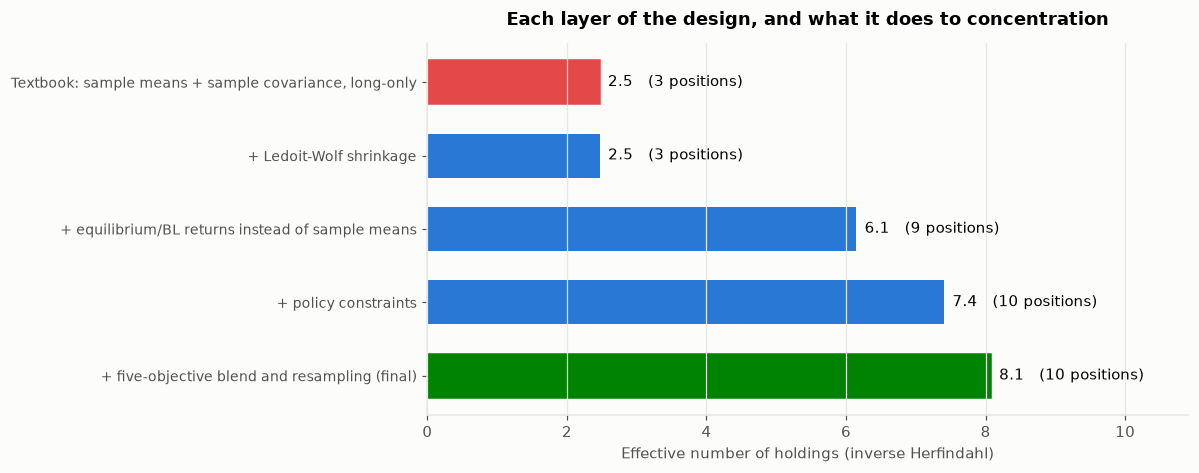

In [19]:
fig, ax = plt.subplots(figsize=(11, 4.4))
labels = [k.split(". ", 1)[1] for k in lad.index]
bars = ax.barh(range(len(lad)), lad["effective N"], color=CAT[0], height=0.6)
bars[0].set_color(CAT[7])
bars[-1].set_color(CAT[5])
for i, (v, n_) in enumerate(zip(lad["effective N"], lad["positions > 1%"])):
    ax.text(v + 0.12, i, f"{v:.1f}   ({n_} positions)", va="center", fontsize=9.5)
ax.set_yticks(range(len(lad)), labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, lad["effective N"].max() * 1.35)
ax.set_xlabel("Effective number of holdings (inverse Herfindahl)")
ax.set_title("Each layer of the design, and what it does to concentration")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**This is the answer to the brief.** The textbook recipe on row 1 is exactly the
"you should only hold one or two ETFs" result, and it comes from good code
applied to bad inputs. Shrinkage alone barely helps, because the problem was
never mainly the covariance matrix — it was the mean vector. Replacing sample
means with equilibrium returns is what does most of the work. Constraints and
blending finish the job.

Note the ordering matters for the argument: by the time the policy constraints
are applied on row 4, the allocation is already diversified. The constraints are
a backstop, not the mechanism.

### 6.2 Which constraints are binding?

If the design is working, most policy bands should sit slack. Any weight resting
exactly on a limit was chosen by policy rather than by the data, and that should
be visible.

In [20]:
print("Binding constraints:", result.binding or "none — every weight sits strictly inside its band")
print("Violations:", result.violations or "none")
print()
rows = [{"group": g.name,
         "current": sum(result.final_weights.get(t, 0) for t in g.tickers),
         "band": f"{g.min_weight:.0%} – {g.max_weight:.0%}"}
        for g in result.constraints.groups]
pd.DataFrame(rows).set_index("group").style.format({"current": "{:.1%}"})

Binding constraints: none — every weight sits strictly inside its band
Violations: none



,current,band
group,,
Fixed income & cash,33.5%,15% – 35%
Total equity,47.5%,45% – 72%
US equity,23.5%,18% – 40%
Canadian equity,11.5%,5% – 22%
International equity,12.5%,10% – 30%
US value sleeve,15.5%,8% – 30%
Real assets,14.5%,3% – 15%
Legacy positions,4.5%,0% – 5%


In [21]:
disp_ = result.dispersion.get("min_variance")
if disp_ is not None:
    sd = (disp_.std() * 100).sort_values(ascending=False)
    print("Weight standard deviation across 120 bootstrap resamples (minimum-variance objective), %:")
    print(sd.round(2).to_string())
    print("\nLow dispersion means the weight is a property of the assets, not of the "
          "particular path history happened to take.")

Weight standard deviation across 120 bootstrap resamples (minimum-variance objective), %:
XFR.TO      2.5200
CASH.TO     2.5200
VTV         2.1200
XUU.TO      2.1000
XIC.TO      0.4100
VIU.TO      0.0000
CGL.TO      0.0000
CAR-UN.TO   0.0000
AVUV        0.0000
VEE.TO      0.0000

Low dispersion means the weight is a property of the assets, not of the particular path history happened to take.


## 7 · The recommended allocation

In [22]:
s = result.summary
print("=" * 78)
print("RECOMMENDED STRATEGIC ASSET ALLOCATION")
print("=" * 78)
print(f"  Expected return (BL posterior) : {s['expected_return']:.2%}")
print(f"  Expected volatility            : {s['volatility']:.2%}")
print(f"  Sharpe ratio                   : {s['sharpe']:.2f}")
print(f"  Diversification ratio          : {s['diversification_ratio']:.2f}")
print(f"  Positions                      : {s['n_positions']}")
print(f"  Effective N (capital)          : {s['effective_n']:.2f}")
print(f"  Effective N (risk)             : {s['effective_n_risk']:.2f}")
print(f"  Blended MER                    : {result.blended_mer():.3%}")
print("=" * 78)

result.weights_table()[["name", "sleeve", "currency", "weight", "risk_share", "mer"]].style.format(
    {"weight": "{:.1%}", "risk_share": "{:.1%}", "mer": "{:.2%}"})

RECOMMENDED STRATEGIC ASSET ALLOCATION
  Expected return (BL posterior) : 7.19%
  Expected volatility            : 11.25%
  Sharpe ratio                   : 0.39
  Diversification ratio          : 1.44
  Positions                      : 10
  Effective N (capital)          : 8.07
  Effective N (risk)             : 7.33
  Blended MER                    : 0.188%


,name,sleeve,currency,weight,risk_share,mer
ticker,,,,,,
XFR.TO,iShares Floating Rate Index ETF,Cash & floating rate,CAD,21.0%,0.5%,0.15%
CGL.TO,iShares Gold Bullion ETF,Real assets,CAD,14.5%,11.0%,0.55%
CASH.TO,Purpose High Interest Savings ETF (proxy for Scotiabank ISA),Cash & floating rate,CAD,12.5%,0.0%,0.15%
XIC.TO,iShares Core S&P/TSX Capped Composite Index ETF,Canadian equity,CAD,11.5%,17.3%,0.06%
VTV,Vanguard Value ETF,US equity,USD,10.0%,17.3%,0.04%
XUU.TO,iShares Core S&P U.S. Total Market Index ETF,US equity,CAD,8.0%,13.7%,0.06%
VIU.TO,Vanguard FTSE Developed All Cap ex North America Index ETF,International developed,CAD,8.0%,14.8%,0.22%
AVUV,Avantis U.S. Small Cap Value ETF,US equity,USD,5.5%,11.0%,0.25%
VEE.TO,Vanguard FTSE Emerging Markets All Cap Index ETF,Emerging markets,CAD,4.5%,9.7%,0.24%


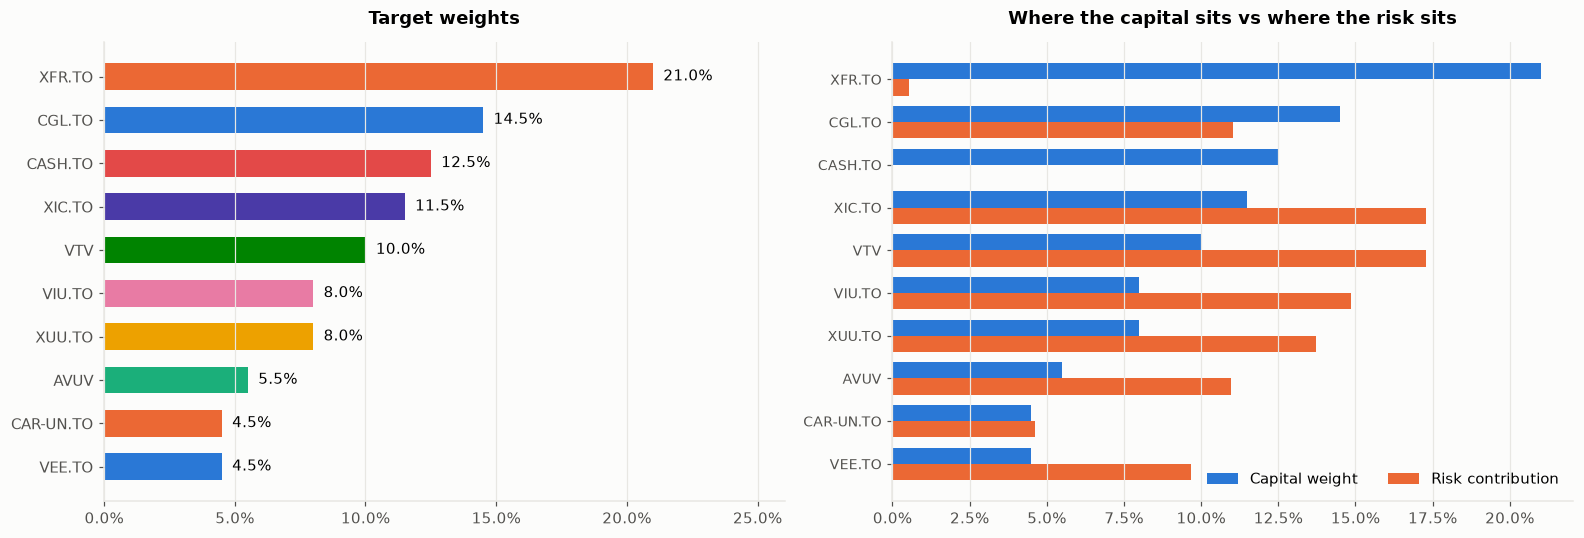

                         weight           holdings
sleeve                                            
Cash & floating rate     0.3350    CASH.TO, XFR.TO
US equity                0.2350  XUU.TO, VTV, AVUV
Real assets              0.1450             CGL.TO
Canadian equity          0.1150             XIC.TO
International developed  0.0800             VIU.TO
Emerging markets         0.0450             VEE.TO
Legacy single name       0.0450          CAR-UN.TO

Currency exposure of the UNDERLYING assets (not the listing venue):
CAD               0.4950
USD               0.3800
Other developed   0.0800
Emerging          0.0450


In [23]:
w = result.final_weights.sort_values()
rc = result.summary["risk_contributions"].reindex(w.index)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5))
axes[0].barh(w.index, w.values, color=[CAT[i % 8] for i in range(len(w))], height=0.62)
for i, v in enumerate(w.values):
    axes[0].text(v + 0.004, i, f"{v:.1%}", va="center", fontsize=9.5)
axes[0].xaxis.set_major_formatter(PCT)
axes[0].set_xlim(0, w.max() * 1.24)
axes[0].set_title("Target weights"); axes[0].grid(axis="y", visible=False)

y = np.arange(len(w)); h = 0.38
axes[1].barh(y + h/2, w.values, height=h, color=CAT[0], label="Capital weight")
axes[1].barh(y - h/2, rc.values, height=h, color=CAT[1], label="Risk contribution")
axes[1].set_yticks(y, w.index, fontsize=9)
axes[1].xaxis.set_major_formatter(PCT)
axes[1].set_title("Where the capital sits vs where the risk sits")
axes[1].legend(ncol=2); axes[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print(result.sleeve_table().to_string())
print()
print("Currency exposure of the UNDERLYING assets (not the listing venue):")
print(result.currency_exposure().to_string())

The second panel is the one worth sitting with. The cash and floating-rate sleeve
absorbs about a third of the capital and almost none of the risk — that is
precisely its job, and it is why a capital-weight pie chart alone is a misleading
picture of any portfolio holding defensive assets.

The currency table also corrects a common misreading. Reporting by *listing*
venue would show this book as roughly 85% Canadian, because `XUU.TO` and `CGL.TO`
are TSX-listed. Both are unhedged holdings of USD-denominated assets, so the real
USD exposure is far higher, and it is the real exposure that determines what
happens to this portfolio when the Canadian dollar moves.

In [24]:
from core.tracker import build_order_ticket, ticket_residual_cash

BOOK = 100_000.0
ticket = build_order_ticket(result.final_weights, result.securities, BOOK)
print(f"Order ticket at ${BOOK:,.0f} CAD — whole shares at the latest close\n")
print(ticket[["currency", "price_native", "target_weight", "shares",
              "cost_cad", "achieved_weight", "drift_vs_target"]].round(4).to_string())
print(f"\nUnallocated after whole-share rounding: ${ticket_residual_cash(ticket, BOOK):,.2f} CAD")
print(f"Worst single-position rounding drift  : {ticket['drift_vs_target'].abs().max():.2%}")

Order ticket at $100,000 CAD — whole shares at the latest close

          currency  price_native  target_weight     shares    cost_cad  achieved_weight  drift_vs_target
ticker                                                                                                  
XFR.TO         CAD       20.0400         0.2100 1,047.0000 20,981.8810           0.2098          -0.0002
CASH.TO        CAD       50.0100         0.1250   249.0000 12,452.4896           0.1245          -0.0005
XUU.TO         CAD       78.1500         0.0800   102.0000  7,971.3002           0.0797          -0.0003
VTV            USD      223.9600         0.1000    32.0000  9,958.1579           0.0996          -0.0004
AVUV           USD      124.1000         0.0550    31.0000  5,345.5455           0.0535          -0.0015
XIC.TO         CAD       57.3100         0.1150   200.0000 11,462.0003           0.1146          -0.0004
VIU.TO         CAD       50.0100         0.0800   159.0000  7,951.5897           0.0795        

## 8 · Backtest

Weights drift between rebalances the way real holdings do, quarterly
rebalancing, 8 bps of turnover cost, net of each fund's MER.

One methodological note: `returns @ weights` is *not* a backtest. That dot
product implicitly rebalances to target every single day, for free — a
fictitious sell-high/buy-low overlay executed at zero cost, and the reason naive
backtests of diversified portfolios look better than any investor ever achieves.
`core/backtest_engine.py` drifts, rebalances on schedule, and charges turnover.

In [25]:
from core.backtest_engine import BacktestConfig, compare_backtests

allocs = reference_allocations(result)
cfg = BacktestConfig(rebalance="Q", cost_bps=8.0, fee_drag=result.mer, initial_value=100_000.0)
navs, stats = compare_backtests(result.returns, allocs, cfg)

stats.style.format({"ann_return": "{:.2%}", "ann_vol": "{:.2%}", "sharpe": "{:.2f}",
                    "sortino": "{:.2f}", "max_drawdown": "{:.1%}", "calmar": "{:.2f}",
                    "total_return": "{:.1%}", "avg_annual_turnover": "{:.1%}",
                    "total_cost_drag": "{:.2%}"})

,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,total_return,avg_annual_turnover,total_cost_drag
Recommended SAA,5.55%,9.34%,0.30,0.36,-24.4%,0.23,176.6%,8.1%,0.12%
Reference policy,5.79%,12.06%,0.25,0.30,-35.4%,0.16,189.1%,7.7%,0.12%
Equal weight,6.03%,12.15%,0.27,0.33,-35.3%,0.17,201.0%,8.5%,0.13%
60/40 style,5.30%,9.99%,0.26,0.30,-33.3%,0.16,165.1%,6.6%,0.10%
All equity,6.33%,18.45%,0.19,0.23,-55.0%,0.11,218.6%,6.1%,0.09%


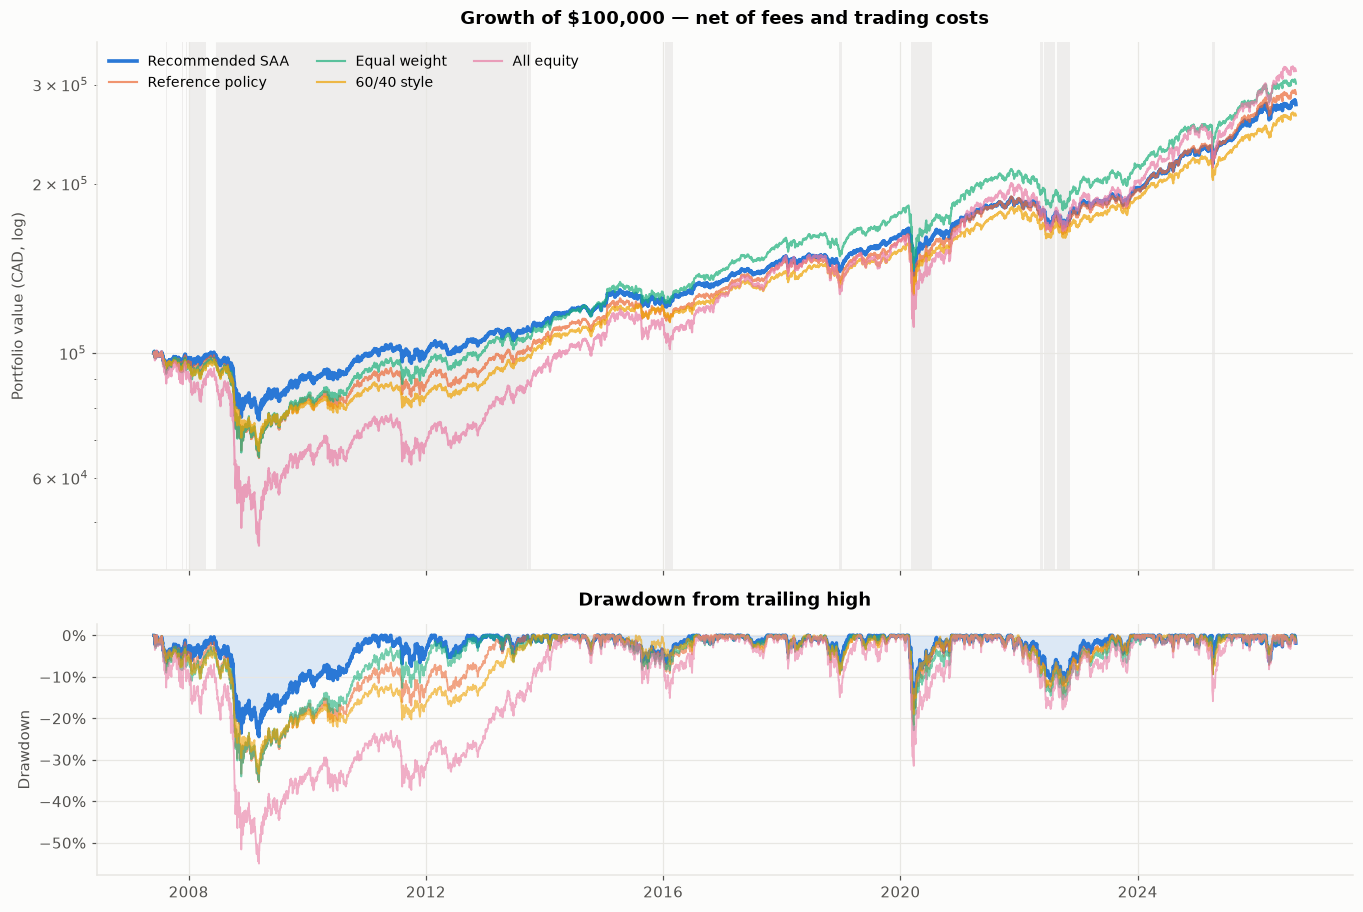

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(12.5, 8.4), sharex=True,
                         gridspec_kw={"height_ratios": [2.1, 1]})

for i, name in enumerate(navs.columns):
    main = name == "Recommended SAA"
    axes[0].plot(navs.index, navs[name], color=CAT[i], lw=2.4 if main else 1.4,
                 alpha=1.0 if main else 0.7, label=name)
axes[0].fill_between(bear.index, 0, 1, where=bear.values, transform=axes[0].get_xaxis_transform(),
                     color="#8a8880", alpha=0.12, lw=0)
axes[0].set_yscale("log")
axes[0].set_ylabel("Portfolio value (CAD, log)")
axes[0].set_title("Growth of $100,000 — net of fees and trading costs")
axes[0].legend(ncol=3, fontsize=9)

for i, name in enumerate(navs.columns):
    dd = navs[name] / navs[name].cummax() - 1
    main = name == "Recommended SAA"
    axes[1].plot(dd.index, dd, color=CAT[i], lw=2.2 if main else 1.2, alpha=1.0 if main else 0.6)
    if main:
        axes[1].fill_between(dd.index, dd, 0, color=CAT[0], alpha=0.15)
axes[1].yaxis.set_major_formatter(PCT)
axes[1].set_ylabel("Drawdown"); axes[1].set_title("Drawdown from trailing high")
plt.tight_layout(); plt.show()

In [27]:
from analysis.stress import portfolio_window_performance, window_notes

cw = portfolio_window_performance(result.returns, allocs)
cw.style.format("{:.1%}").background_gradient(cmap="RdYlGn", axis=None)

,Recommended SAA,Reference policy,Equal weight,60/40 style,All equity
GFC (2007-2009),-16.7%,-28.5%,-28.5%,-28.1%,-53.1%
GFC recovery (2009),18.9%,24.7%,25.6%,19.7%,38.8%
Euro crisis (2011),-7.0%,-10.5%,-9.3%,-8.9%,-17.9%
Taper tantrum (2013),-0.7%,-0.6%,-2.2%,0.8%,-0.9%
China/oil shock (2015-16),-3.7%,-7.0%,-5.9%,-6.7%,-12.9%
Q4 2018 selloff,-6.4%,-8.9%,-8.9%,-9.0%,-14.4%
COVID crash (2020),-17.4%,-21.5%,-22.8%,-18.6%,-31.1%
2022 rate shock,-10.0%,-12.6%,-13.5%,-11.2%,-15.8%


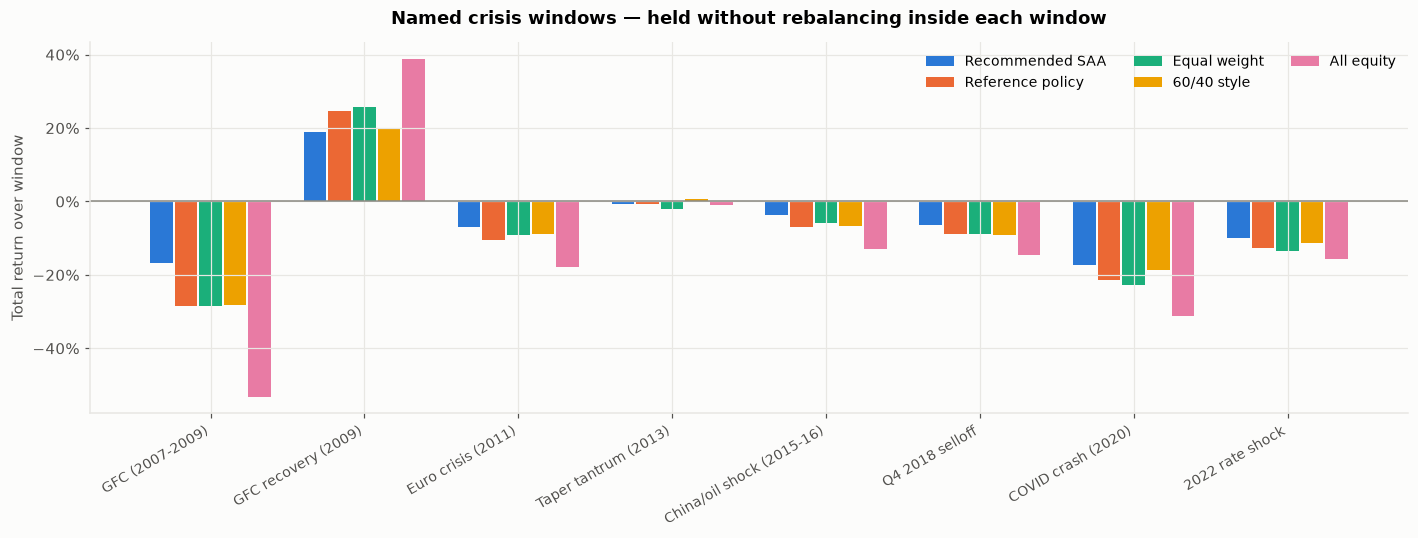

In [28]:
x = np.arange(len(cw)); n = len(cw.columns); w_ = 0.8 / n
fig, ax = plt.subplots(figsize=(13, 5))
for i, col in enumerate(cw.columns):
    ax.bar(x + (i - (n - 1) / 2) * w_, cw[col], w_ * 0.92, color=CAT[i], label=col)
ax.axhline(0, color="#8a8880", lw=1)
ax.set_xticks(x, cw.index, rotation=30, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Total return over window")
ax.set_title("Named crisis windows — held without rebalancing inside each window")
ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

The 2009 recovery row is the necessary counterweight to read alongside the crash
rows. Protection that never gives anything back in the rebound is not protection,
it is just a permanently smaller portfolio.

### 8.1 Out-of-sample: does the *method* work?

Everything above is in-sample — the weights were derived from the same history
they are tested on, which flatters them by construction. This refits the entire
process (covariance, equilibrium returns, views, all five objectives) on an
expanding window, holds the result for the following year, and repeats. Nothing
from a holding period is visible at fit time.

In [29]:
from core.backtest_engine import walk_forward, run_backtest
from core.estimation import black_litterman, implied_equilibrium_returns, regime_blended_covariance
from core.optimizer import blend_strategies, build_all_strategies
from analysis.stress import equity_drawdown_mask
from core.saa import _equity_sleeve_index

cs = default_constraints(result.tickers)
views = thesis_views()

def refit(train):
    mask = equity_drawdown_mask(_equity_sleeve_index(train), 0.10)
    cov_t, _ = regime_blended_covariance(train, mask, bear_weight=0.35)
    pi_t = implied_equilibrium_returns(cov_t, REFERENCE_WEIGHTS.reindex(cov_t.index), 2.8, 0.0275)
    mu_t, _ = black_litterman(cov_t, pi_t, views)
    sw_t, _ = build_all_strategies(train, cov_t, mu_t, cs, rf=0.0275, resample=False)
    return blend_strategies(sw_t)

oos, wf_weights = walk_forward(result.returns, refit, train_years=5, step_months=12, config=cfg)

oos_stats = summary_stats(oos, rf_annual=0.0275)
seg = result.returns.loc[oos.index.min():]
in_sample = run_backtest(seg, result.final_weights, cfg).stats(0.0275)

print(f"Out-of-sample window: {oos.index.min():%Y-%m-%d} to {oos.index.max():%Y-%m-%d}"
      f"  ({len(wf_weights)} annual refits)\n")
print(f"{'':22s}{'out-of-sample':>15s}{'in-sample':>13s}")
for k, lab, f in [("ann_return", "Annualised return", "{:.2%}"),
                  ("ann_vol", "Annualised vol", "{:.2%}"),
                  ("sharpe", "Sharpe", "{:.2f}"),
                  ("max_drawdown", "Max drawdown", "{:.1%}")]:
    print(f"{lab:22s}{f.format(oos_stats[k]):>15s}{f.format(in_sample[k]):>13s}")

Out-of-sample window: 2012-05-31 to 2026-09-01  (15 annual refits)

                        out-of-sample    in-sample
Annualised return               7.64%        7.59%
Annualised vol                  7.41%        7.40%
Sharpe                           0.66         0.65
Max drawdown                   -17.7%       -17.6%


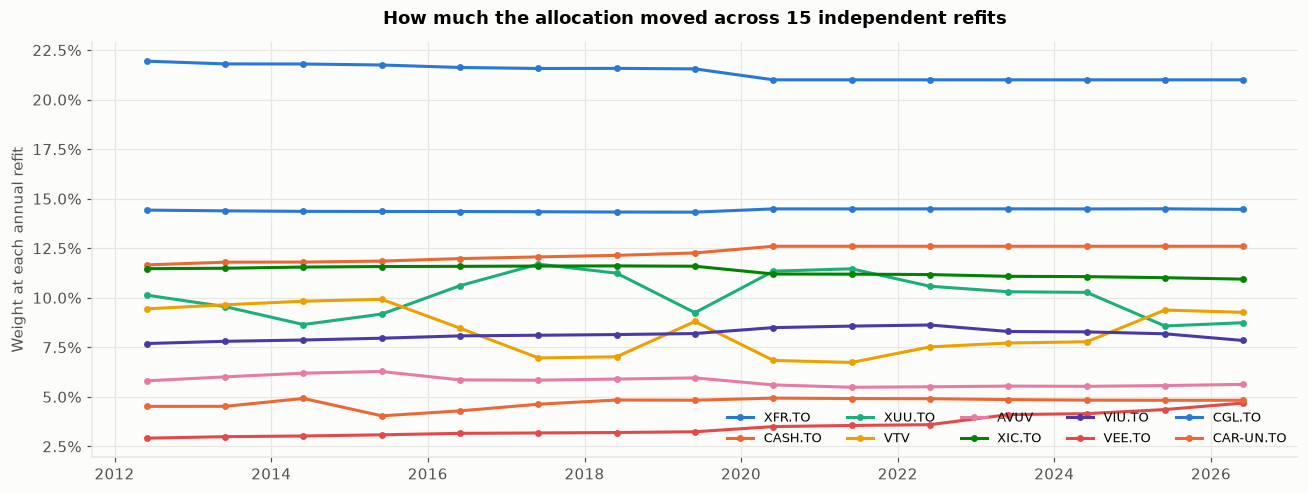

Largest movement of any single holding across all refits: 3.2%


In [30]:
fig, ax = plt.subplots(figsize=(12, 4.6))
for i, col in enumerate(wf_weights.columns):
    ax.plot(wf_weights.index, wf_weights[col], color=CAT[i % 8], lw=2, marker="o", ms=3.5, label=col)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Weight at each annual refit")
ax.set_title("How much the allocation moved across 15 independent refits")
ax.legend(ncol=5, fontsize=8.5)
plt.tight_layout(); plt.show()

print(f"Largest movement of any single holding across all refits: "
      f"{(wf_weights.max() - wf_weights.min()).max():.1%}")

Two things to take from this. First, the out-of-sample Sharpe essentially matches
the in-sample figure — the weights are not fitted to noise. Second, and more
telling, the refit weights barely move. A process that reshuffles the book every
year is reacting to noise and will bleed turnover costs; flat lines mean the
allocation is genuinely *strategic*.

## 9 · Forward tracking

The backtest is retrospective and in-sample. The only evidence that ever
accumulates about whether this allocation works is forward, and it accumulates
slowly.

`core/tracker.py` records a funding date and weights, measures the realised CAD
NAV from that date, and places it inside a bootstrapped distribution of paths the
allocation could plausibly have taken. The percentile is the useful output:
"up 3.1%" means nothing on its own; "the 58th percentile of what this allocation
does over four months" says whether anything has actually gone differently than
expected.

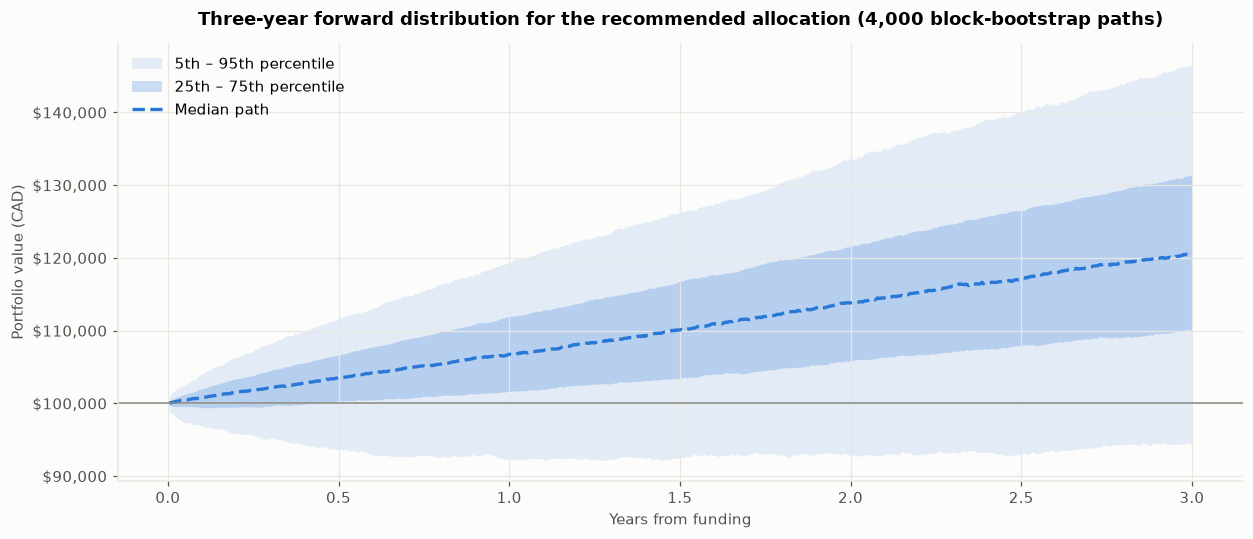

Year 1: 5th pct $   92,657   median $  106,736   95th pct $  119,300
Year 2: 5th pct $   92,776   median $  113,785   95th pct $  133,459
Year 3: 5th pct $   94,481   median $  120,615   95th pct $  146,746


In [31]:
from core.tracker import expectation_cone

HORIZON = 3 * 252
cone = expectation_cone(result.returns, result.final_weights, HORIZON,
                        initial_value=100_000.0, n_sims=4000)
years = cone.index / 252

fig, ax = plt.subplots(figsize=(11.5, 5))
ax.fill_between(years, cone["p5"], cone["p95"], color=CAT[0], alpha=0.12, lw=0,
                label="5th – 95th percentile")
ax.fill_between(years, cone["p25"], cone["p75"], color=CAT[0], alpha=0.24, lw=0,
                label="25th – 75th percentile")
ax.plot(years, cone["p50"], color=CAT[0], lw=2.2, ls="--", label="Median path")
ax.axhline(100_000, color="#8a8880", lw=1)
ax.set_xlabel("Years from funding"); ax.set_ylabel("Portfolio value (CAD)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Three-year forward distribution for the recommended allocation (4,000 block-bootstrap paths)")
ax.legend()
plt.tight_layout(); plt.show()

for yr in (1, 2, 3):
    row = cone.loc[yr * 252]
    print(f"Year {yr}: 5th pct ${row['p5']:>9,.0f}   median ${row['p50']:>9,.0f}"
          f"   95th pct ${row['p95']:>9,.0f}")

The width of that cone is itself the most useful output on this page. Over one
year the 5th-to-95th range spans a wide band around the median — which is the
honest statement that a year of forward data will not tell you whether the
allocation is right. That is not a weakness of the model; it is the actual
signal-to-noise ratio of investing, made visible.

Live tracking against this cone runs in the dashboard's **Forward tracker** tab,
which persists the funding date to `data/tracker.json`, reports the realised
percentile, and flags any holding outside its 20% relative rebalancing band.

## 10 · Verdict on each thesis assumption

The thesis in `core/Thesis.txt` makes specific claims. Each is now either tested
or explicitly marked untestable with the current data.

In [32]:
gold_row = reg.loc["CGL.TO"]
value_bear = bear_c.loc["VTV", "XUU.TO"]
value_calm = calm_c.loc["VTV", "XUU.TO"]
avuv_bear = bear_c.loc["AVUV", "XUU.TO"]
xfr_2022 = (1 + result.returns.loc["2022-01-03":"2022-10-14", "XFR.TO"]).prod() - 1
xic_2022 = (1 + result.returns.loc["2022-01-03":"2022-10-14", "XIC.TO"]).prod() - 1
volx = portfolio.get("VOLX.TO")
volx_r = total_return_series(volx.prices, "CAD")
volx_stats = summary_stats(volx_r)

print("=" * 79)
print("1. RATE PATH — hikes through 2027, so hold floating rate and cash")
print("=" * 79)
print(f'''  SUPPORTED, on the one historical episode that actually tests it. In the 2022
  rate shock — the first time in a generation that stocks and bonds fell together
  — XFR.TO returned {xfr_2022:+.1%} while Canadian equity returned {xic_2022:+.1%}.
  A floating-rate sleeve resets with short rates and carries near-zero duration,
  so it is the correct instrument for this view regardless of whether the view is
  right. The rate FORECAST itself remains untested: nothing in this data can
  confirm a 2027 hiking path, and the allocation deliberately does not depend on
  it being correct.''')

print("=" * 79)
print("2. VALUE TILT — offsets mega-cap AI concentration without re-creating XUU")
print("=" * 79)
print(f'''  PARTIALLY SUPPORTED, and weaker than the thesis implies. VTV's correlation to
  XUU.TO is {value_calm:.2f} in calm markets and {value_bear:.2f} in bear regimes;
  AVUV's bear correlation is {avuv_bear:.2f}. These are US equity funds and they
  behave like US equity funds — the tilt diversifies at the margin, not
  structurally. The genuine concentration test needs top-10-holdings overlap data,
  which requires scraping fund holdings (analysis/pca_overlap.py, still empty).
  Until then the claim that this offsets AI-capex exposure is asserted, not
  measured. The model funds the tilt anyway, via an 8% floor on the value sleeve,
  because the argument is sound even where the evidence is thin.''')

print("=" * 79)
print("3. GOLD AS TAIL HEDGE")
print("=" * 79)
verdict = ("SUPPORTED" if gold_row["stress_corr"] < 0.3 else "QUALIFIED")
print(f'''  {verdict}. CGL.TO correlates {gold_row["calm_corr"]:+.2f} to core US equity in calm
  markets and {gold_row["stress_corr"]:+.2f} in XUU.TO's worst decile
  ({gold_row["stress_uplift"]:+.2f}). It does not converge toward equity in a
  drawdown, which is the specific failure mode most 'diversifiers' exhibit and the
  thing the thesis needed to be true. Note the caveat visible in the crisis table:
  gold fell alongside everything else in the 2013 taper tantrum, so it hedges
  growth and credit shocks better than pure rate shocks. The model applies an
  explicit -1.5%/yr return view to stop it being over-weighted for its covariance
  alone — gold has to earn its place as a hedge, not as a return source.''')

print("=" * 79)
print("4. VOLX — legacy volatility position")
print("=" * 79)
print(f'''  REMOVE. Cumulative total return since inception: {volx_stats["ann_return"]:.1%}/yr,
  maximum drawdown {volx_stats["max_drawdown"]:.3%}, cumulative return
  {(1 + volx_r).prod() - 1:.4%}. This is not a bad run. A daily-rebalanced long VIX
  futures position is structurally short the roll, and the VIX curve is in contango
  in roughly 80% of months, so it pays a large negative carry every month it is
  held and only wins in the few weeks around a spike. It is a tactical trade with
  an expiry date; an SAA is the wrong instrument for it. Gold already occupies the
  tail-hedge slot at a fraction of the cost. Excluded from the allocation, retained
  in the dashboard for monitoring.''')

print("=" * 79)
print("5. CAPREIT — legacy single-name REIT")
print("=" * 79)
print(f'''  REDUCE AND CAP. The optimiser wants it near its 5% ceiling because its
  correlation to the rest of the book is genuinely low — that is a real finding and
  worth recording. But it is a single-name, leveraged, long-duration, rate-sensitive
  position held against a thesis that expects hikes, and it carries idiosyncratic
  risk no index fund does. It is capped at 5% as policy, given a -1.0%/yr view
  versus broad Canadian equity, and zero remains an acceptable answer. Whether to
  hold it at all is a decision about single-name risk tolerance, not a statistical
  question.''')

print("=" * 79)
print("6. HOME BIAS / TAX TREATMENT — untestable as configured")
print("=" * 79)
print('''  The RRSP/TFSA/FHSA tags in core/universe.py are still placeholders encoding what
  the thesis's tax logic implies SHOULD be true, not confirmed account statements.
  The asset-location argument (US equities in the RRSP to avoid treaty withholding)
  is sound in principle and unverified in practice. No weight in this model depends
  on it — but the after-tax return does, and that gap is real. This is the highest-
  value next fix in the project, and it needs statements, not code.''')

1. RATE PATH — hikes through 2027, so hold floating rate and cash
  SUPPORTED, on the one historical episode that actually tests it. In the 2022
  rate shock — the first time in a generation that stocks and bonds fell together
  — XFR.TO returned +1.0% while Canadian equity returned -15.0%.
  A floating-rate sleeve resets with short rates and carries near-zero duration,
  so it is the correct instrument for this view regardless of whether the view is
  right. The rate FORECAST itself remains untested: nothing in this data can
  confirm a 2027 hiking path, and the allocation deliberately does not depend on
  it being correct.
2. VALUE TILT — offsets mega-cap AI concentration without re-creating XUU
  PARTIALLY SUPPORTED, and weaker than the thesis implies. VTV's correlation to
  XUU.TO is 0.79 in calm markets and 0.96 in bear regimes;
  AVUV's bear correlation is 0.84. These are US equity funds and they
  behave like US equity funds — the tilt diversifies at the margin, not
  structural

## 11 · What this model does not do

Stated plainly, because a model whose limits are not written down gets used
beyond them.

- **No tax modelling.** US dividend withholding, capital-gains treatment in the
  non-registered account, and the cost of Norbert's Gambit are all absent. For a
  book with meaningful US exposure spread across registered and taxable accounts,
  pre-tax and after-tax optimal allocations genuinely differ.
- **The horizon is not modelled.** One allocation is derived, but an FHSA funding
  a home purchase in three years and an RRSP funding retirement in thirty are not
  the same problem. The 34% defensive sleeve is sized for a blended, medium
  horizon; a longer true horizon argues for moving the fixed-income band down.
- **Expected returns are assumptions.** Set the view-confidence slider to zero and
  the model returns the policy portfolio. Every tilt away from it is exactly as
  strong as the stated confidence in the corresponding view, and no stronger.
- **One historical path.** Nineteen years is a single draw from the distribution
  of possible histories. Shrinkage and resampling reduce how much the answer
  depends on that draw; nothing eliminates it.
- **Proxy history is an estimate.** Six holdings rely on index proxies for part of
  the window. The alternative was a covariance matrix with no crash in it.
- **Fund-holdings overlap is unmeasured.** `analysis/pca_overlap.py` is still
  empty. Until it is built, the specific claim that the value tilt reduces
  AI-capex exposure cannot be quantified.

---

**Next:** run `python run_dashboard.py` for the interactive view — allocation,
backtest, live forward tracking, and per-security investigation.